# Existing code for Database operations

In [1]:
from db_manager import DatabaseManager


In [2]:
db_manager = DatabaseManager()

In [11]:
db_manager.create_database('university')

(True, "Database 'university' created successfully")

In [12]:
db_manager.list_databases()

['mydb2', 'university']

In [13]:
student_schema = {
    "student_id": int,
    "name": str,
    "Phone": str,
    "age": float,
    "Branch": str
}

In [14]:
prof = {
    "prof_id": int,
    "name": str,
    "Phone": str,
    "age": float,
    "salary": int,
    "department": str
}

In [15]:
db_manager.create_table('university', 'professor', prof, order=6, search_key= "prof_id")

(True, "Table 'professor' created successfully in database 'university'")

In [16]:
db_manager.create_table('university', 'student', student_schema, order=6, search_key= "student_id")

(True, "Table 'student' created successfully in database 'university'")

In [17]:
tables_name, _ = db_manager.list_tables('university')
tables_name

['professor', 'student']

In [18]:
table_stu, _ = db_manager.get_table('university', 'student')
table_stu.get_all()

[]

In [35]:
rec = {
    "student_id": 9,
    "name": "xyzf",
    "Phone": "846699",
    "age": 26.0,
    "Branch": "pech Eng1"
}

### INsertion

In [36]:
table_stu.insert(rec)

(True, 9)

### Search

In [21]:
table_stu.get(6)


{'student_id': 6,
 'name': 'xyzf',
 'Phone': '846699',
 'age': 26.0,
 'Branch': 'pech Eng1'}

### Update

In [41]:
new_rec = {'student_id': 25,
 'name': 'xyzf',
 'Phone': '846',
 'age': 26.0,
 'Branch': 'pech Eng1'}

In [ ]:
table_stu.update(9, new_rec)

(True, 'Record updated')

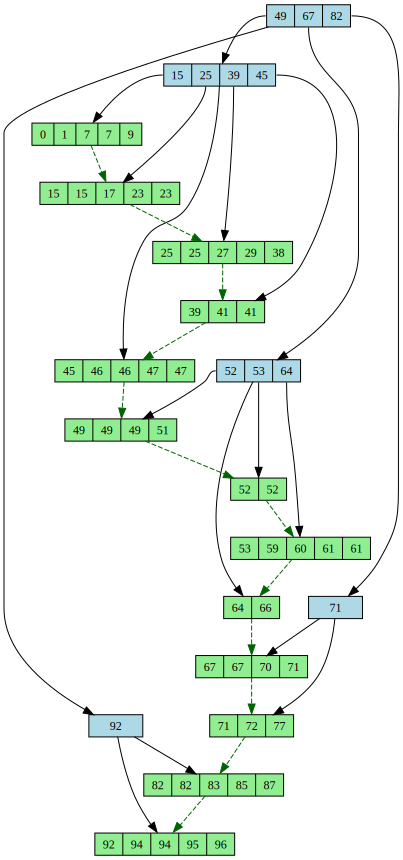

In [47]:
from IPython.display import SVG, display

dot = table_stu.data.visualize_tree()
svg_data = dot.pipe(format='svg').decode('utf-8')
display(SVG(svg_data))

### Deletion

In [42]:
table_stu.delete(6)

(True, 'Record deleted')

### Range Query

In [45]:
import random
import string

def random_record_generator(schema, n):
    def random_value(data_type):
        if data_type == int:
            return random.randint(1, 100)
        elif data_type == float:
            return round(random.uniform(18.0, 60.0), 2)
        elif data_type == str:
            return ''.join(random.choices(string.ascii_letters, k=6))
        else:
            return None  # Unknown type

    records = []
    for _ in range(n):
        record = {}
        for field, field_type in schema.items():
            record[field] = random_value(field_type)
        records.append(record)
    return records

In [46]:
import pandas as pd
records = random_record_generator(student_schema, 50)

for rec in records:
    table_stu.insert(rec)
 

In [48]:
table_stu.range_query(63, 70)

[(64,
  {'student_id': 64,
   'name': 'PRpIqg',
   'Phone': 'kHSDRP',
   'age': 26.7,
   'Branch': 'STXUyO'}),
 (66,
  {'student_id': 66,
   'name': 'TLKxuT',
   'Phone': 'nCHjRx',
   'age': 34.59,
   'Branch': 'TzVIbd'}),
 (67,
  {'student_id': 67,
   'name': 'aRzfuh',
   'Phone': 'HFCVxY',
   'age': 46.32,
   'Branch': 'yoZNom'}),
 (67,
  {'student_id': 67,
   'name': 'YDrHyk',
   'Phone': 'ZrqWQI',
   'age': 22.05,
   'Branch': 'wAZXxy'}),
 (70,
  {'student_id': 70,
   'name': 'ZavVCx',
   'Phone': 'ZDgLsO',
   'age': 44.03,
   'Branch': 'zCWZsu'})]

# Module-A

In [1]:
#imports
from bplustree import BPlusTree
from performance_analyzer import PerformanceAnalyzer
from IPython.display import SVG, display
import pandas as pd
import random
import string

### 1. Constructing B+ Tree
Using `Product` Schema: `ProductID`, `Name`, `Price`, `StockQuantity`, `ReorderLevel`, `CategoryID`.

B+ tree using random records

In [3]:
def random_record_generator(schema, n):
    def random_value(data_type):
        if data_type == int:
            return random.randint(1, 1000)
        elif data_type == float:
            return round(random.uniform(10, 1000), 2)
        elif data_type == str:
            return ''.join(random.choices(string.ascii_letters, k=8))
        return None

    records = []
    for i in range(1, n + 1):
        record = {}
        for field, field_type in schema.items():
            if field == 'ProductID':
                record[field] = i
            else:
                record[field] = random_value(field_type)
        records.append(record)

    return records

In [4]:
schema = {
    'ProductID': int,
    'Name': str,
    'Price': float,
    'StockQuantity': int,
    'ReorderLevel': int,
    'CategoryID': int
}

product_tree_r = BPlusTree(order=6)

records = random_record_generator(schema, 20)

for record in records:
    product_tree_r.insert(record['ProductID'], record)
    
df = pd.DataFrame([value for _, value in product_tree_r.get_all()])
df.head(5).style.hide(axis="index")

ProductID,Name,Price,StockQuantity,ReorderLevel,CategoryID
1,DIhGQnjc,172.530000,733,25,784
2,YCMJxxaD,939.330000,553,513,992
3,VoKBnafd,75.040000,53,929,793
4,QchKCtxa,276.330000,469,604,130
5,PrjJBunR,425.830000,498,53,266


Manula records entry

In [5]:
product_tree = BPlusTree(order=6)
product_records = [
    (1, {'ProductID': 1, 'Name': 'Smartphone', 'Price': 15000.00, 'StockQuantity': 50, 'ReorderLevel': 5, 'CategoryID': 1}),
    (2, {'ProductID': 2, 'Name': 'Laptop', 'Price': 55000.00, 'StockQuantity': 20, 'ReorderLevel': 3, 'CategoryID': 1}),
    (3, {'ProductID': 3, 'Name': 'Headphones', 'Price': 2000.00, 'StockQuantity': 100, 'ReorderLevel': 10, 'CategoryID': 1}),
    (4, {'ProductID': 4, 'Name': 'Rice (5kg)', 'Price': 300.00, 'StockQuantity': 200, 'ReorderLevel': 20, 'CategoryID': 2}),
    (5, {'ProductID': 5, 'Name': 'Wheat Flour (10kg)', 'Price': 400.00, 'StockQuantity': 150, 'ReorderLevel': 15, 'CategoryID': 2}),
    (6, {'ProductID': 6, 'Name': 'Milk (1L)', 'Price': 60.00, 'StockQuantity': 300, 'ReorderLevel': 30, 'CategoryID': 2}),
    (7, {'ProductID': 7, 'Name': 'T-Shirt (Men)', 'Price': 500.00, 'StockQuantity': 80, 'ReorderLevel': 10, 'CategoryID': 3}),
    (8, {'ProductID': 8, 'Name': 'Jeans (Women)', 'Price': 1200.00, 'StockQuantity': 60, 'ReorderLevel': 8, 'CategoryID': 3}),
    (9, {'ProductID': 9, 'Name': 'Notebook', 'Price': 50.00, 'StockQuantity': 500, 'ReorderLevel': 50, 'CategoryID': 4}),
    (10, {'ProductID': 10, 'Name': 'Pen Pack (10)', 'Price': 100.00, 'StockQuantity': 400, 'ReorderLevel': 40, 'CategoryID': 4}),
    (11, {'ProductID': 11, 'Name': 'Non-stick Pan', 'Price': 800.00, 'StockQuantity': 40, 'ReorderLevel': 5, 'CategoryID': 5}),
    (12, {'ProductID': 12, 'Name': 'Bedsheet', 'Price': 1500.00, 'StockQuantity': 30, 'ReorderLevel': 4, 'CategoryID': 5}),
    (13, {'ProductID': 13, 'Name': 'Shampoo (200ml)', 'Price': 180.00, 'StockQuantity': 120, 'ReorderLevel': 15, 'CategoryID': 6}),
    (14, {'ProductID': 14, 'Name': 'Soap (pack of 3)', 'Price': 90.00, 'StockQuantity': 200, 'ReorderLevel': 20, 'CategoryID': 6}),
    (15, {'ProductID': 15, 'Name': 'Cricket Bat', 'Price': 2500.00, 'StockQuantity': 25, 'ReorderLevel': 3, 'CategoryID': 7}),
    (16, {'ProductID': 16, 'Name': 'Football', 'Price': 800.00, 'StockQuantity': 40, 'ReorderLevel': 5, 'CategoryID': 7}),
    (17, {'ProductID': 17, 'Name': 'Lego Set', 'Price': 1200.00, 'StockQuantity': 35, 'ReorderLevel': 4, 'CategoryID': 8}),
    (18, {'ProductID': 18, 'Name': 'Doll', 'Price': 600.00, 'StockQuantity': 50, 'ReorderLevel': 6, 'CategoryID': 8}),
    (19, {'ProductID': 19, 'Name': 'Coffee Powder (250g)', 'Price': 250.00, 'StockQuantity': 80, 'ReorderLevel': 10, 'CategoryID': 2}),
    (20, {'ProductID': 20, 'Name': 'Umbrella', 'Price': 350.00, 'StockQuantity': 60, 'ReorderLevel': 8, 'CategoryID': 5}),
]
for key, value in product_records:
    product_tree.insert(key, value)

df=pd.DataFrame([value for _, value in product_tree.get_all()])
df.head(5).style.hide(axis="index")

ProductID,Name,Price,StockQuantity,ReorderLevel,CategoryID
1,Smartphone,15000.000000,50,5,1
2,Laptop,55000.000000,20,3,1
3,Headphones,2000.000000,100,10,1
4,Rice (5kg),300.000000,200,20,2
5,Wheat Flour (10kg),400.000000,150,15,2


### 2. Core Operations (Insertion, Search, Deletion, Range Query)

In [6]:
# Insert a new product
new_product = {
    'ProductID': 21,
    'Name': 'Water Bottle',
    'Price': 180.00,
    'StockQuantity': 120,
    'ReorderLevel': 12,
    'CategoryID': 5,
}
product_tree.insert(new_product['ProductID'], new_product)

In [7]:
# Search
search_result = product_tree.search(5)
search_result

{'ProductID': 5,
 'Name': 'Wheat Flour (10kg)',
 'Price': 400.0,
 'StockQuantity': 150,
 'ReorderLevel': 15,
 'CategoryID': 2}

In [8]:
# Delete and verify
deleted = product_tree.delete(6)
after_delete = product_tree.search(6)
deleted, after_delete

(True, None)

In [9]:
# Range query (ProductID 3 to 10)
range_result = product_tree.range_query(4, 7)
range_result

[(4,
  {'ProductID': 4,
   'Name': 'Rice (5kg)',
   'Price': 300.0,
   'StockQuantity': 200,
   'ReorderLevel': 20,
   'CategoryID': 2}),
 (5,
  {'ProductID': 5,
   'Name': 'Wheat Flour (10kg)',
   'Price': 400.0,
   'StockQuantity': 150,
   'ReorderLevel': 15,
   'CategoryID': 2}),
 (7,
  {'ProductID': 7,
   'Name': 'T-Shirt (Men)',
   'Price': 500.0,
   'StockQuantity': 80,
   'ReorderLevel': 10,
   'CategoryID': 3})]

### 3. Graphviz Tree Visualisation
Tree visualization containing internal/leaf nodes and dashed `next` links between leaf nodes.

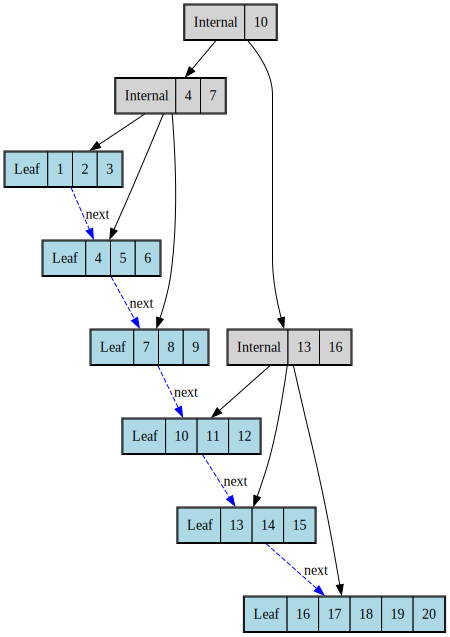

In [10]:
dot = product_tree_r.visualize_tree()
svg_data = dot.pipe(format='svg').decode('utf-8')
display(SVG(svg_data))

In [12]:
from pathlib import Path
from graphviz import Digraph

# Pick the source tree already built in this notebook.
source_tree = product_tree_r if 'product_tree_r' in globals() else product_tree

# Build Graphviz output in the same visual style as the pasted sample.
dot = Digraph(comment='B+ Tree')

def _record_label(node):
    kind = 'Leaf' if node.is_leaf else 'Internal'
    return ' | '.join([kind] + [str(k) for k in node.keys])

def _add_subtree(node):
    node_id = str(id(node))
    fill = 'lightblue' if node.is_leaf else 'lightgray'
    dot.node(node_id, label=_record_label(node), shape='record', style='filled', fillcolor=fill)

    if node.is_leaf:
        return

    for child in node.children:
        child_id = str(id(child))
        _add_subtree(child)
        dot.edge(node_id, child_id)

_add_subtree(source_tree.root)

output_dir = Path('../database/visualizations')
output_dir.mkdir(parents=True, exist_ok=True)

dot_path = output_dir / 'product_tree.dot'
png_base = output_dir / 'product_tree'

dot.save(str(dot_path))
dot.render(filename=str(png_base), format='png', cleanup=True)

print(f'DOT saved to: {dot_path.resolve()}')
print(f'PNG saved to: {(output_dir / "product_tree.png").resolve()}')

DOT saved to: D:\AKASH.O\Downloads\DB_A2\Module_A\database\visualizations\product_tree.dot
PNG saved to: D:\AKASH.O\Downloads\DB_A2\Module_A\database\visualizations\product_tree.png


Splitting of Nodes

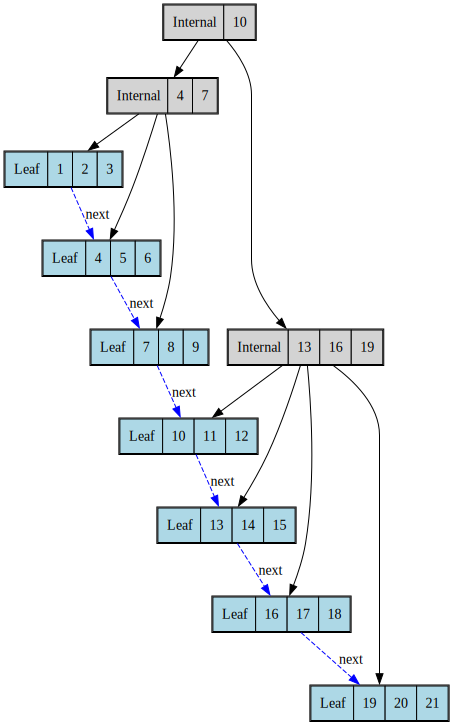

In [ ]:
new_product = {
    'ProductID': 21,
    'Name': 'Coffee Maker',
    'Price': 5000.00,
    'StockQuantity': 100,
    'ReorderLevel': 16,
    'CategoryID': 8,
}
product_tree_r.insert(new_product['ProductID'], new_product)

dot = product_tree_r.visualize_tree()
svg_data = dot.pipe(format='svg').decode('utf-8')
display(SVG(svg_data))

Merging of Nodes

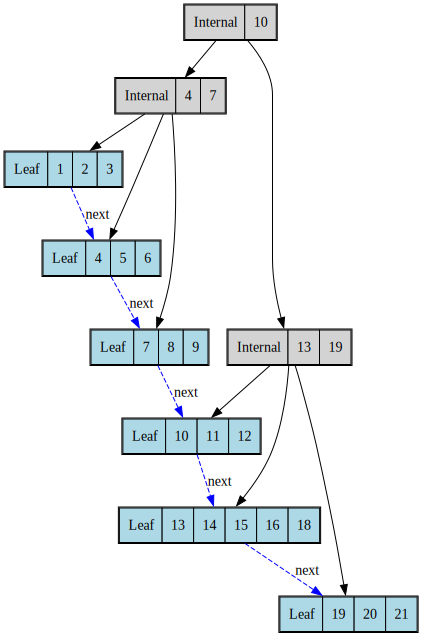

In [ ]:
deleted = product_tree_r.delete(17)

dot = product_tree_r.visualize_tree()
svg_data = dot.pipe(format='svg').decode('utf-8')
display(SVG(svg_data))

### 4. Performance Testing (B+ Tree vs Brute Force)
Using small sizes first for quick checks, then switching to full range.

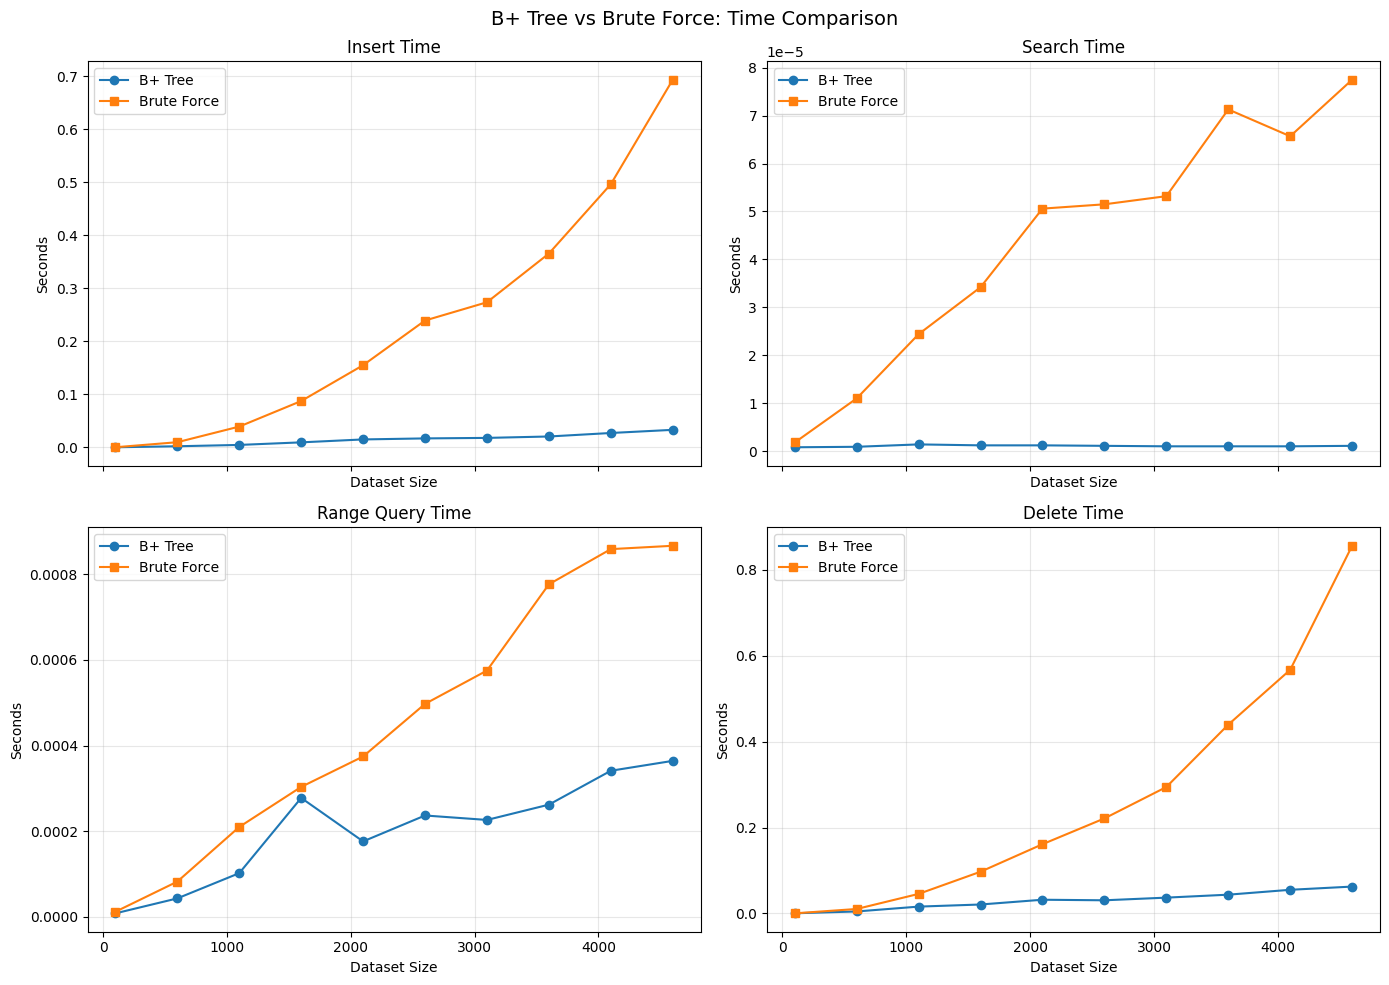

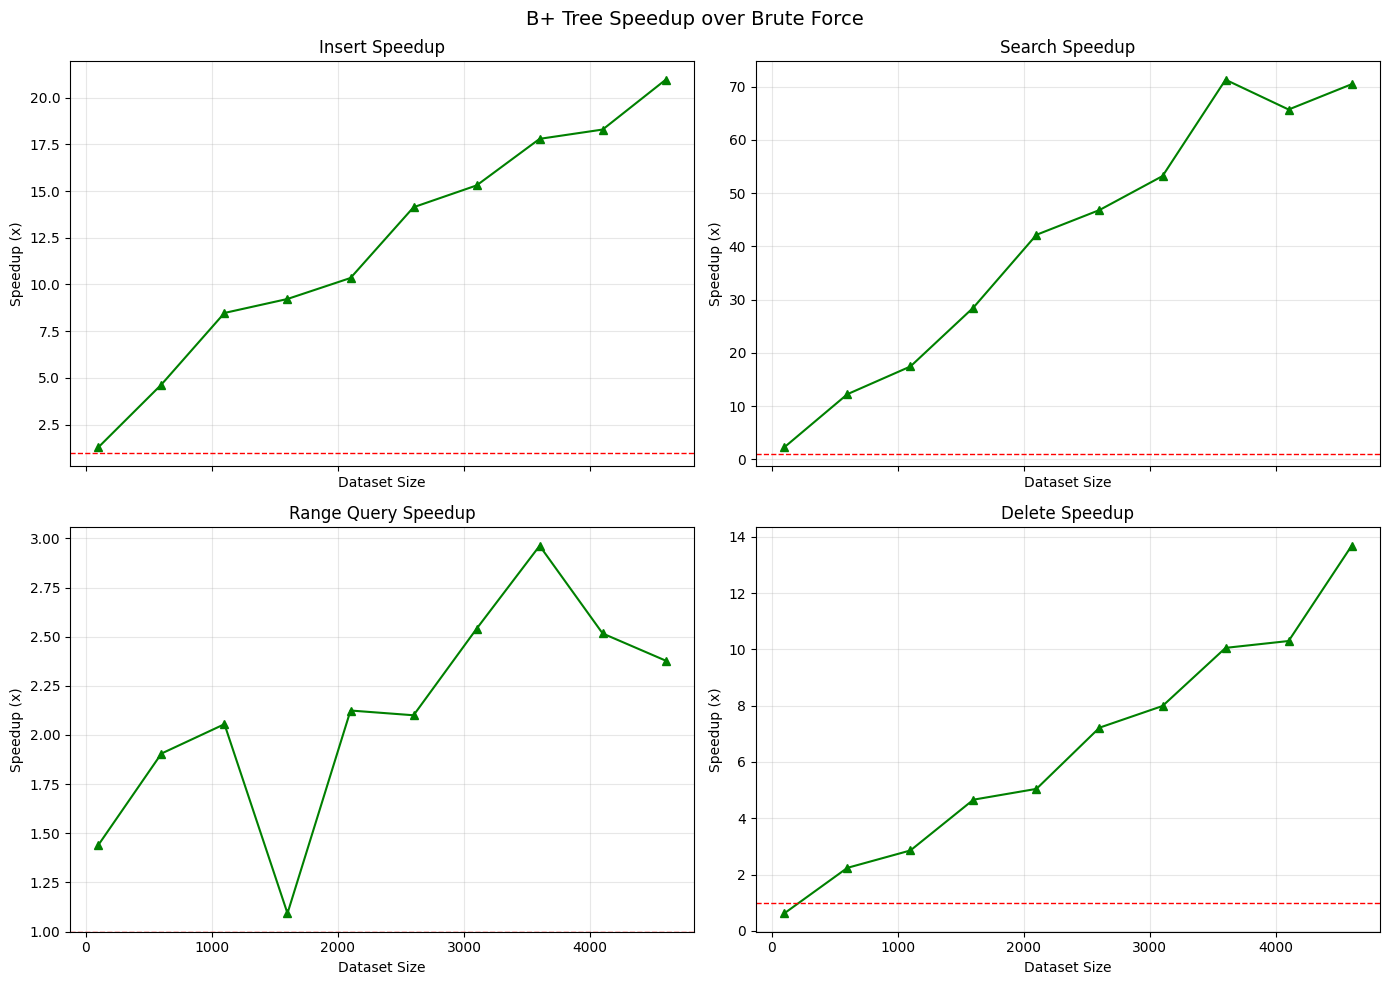

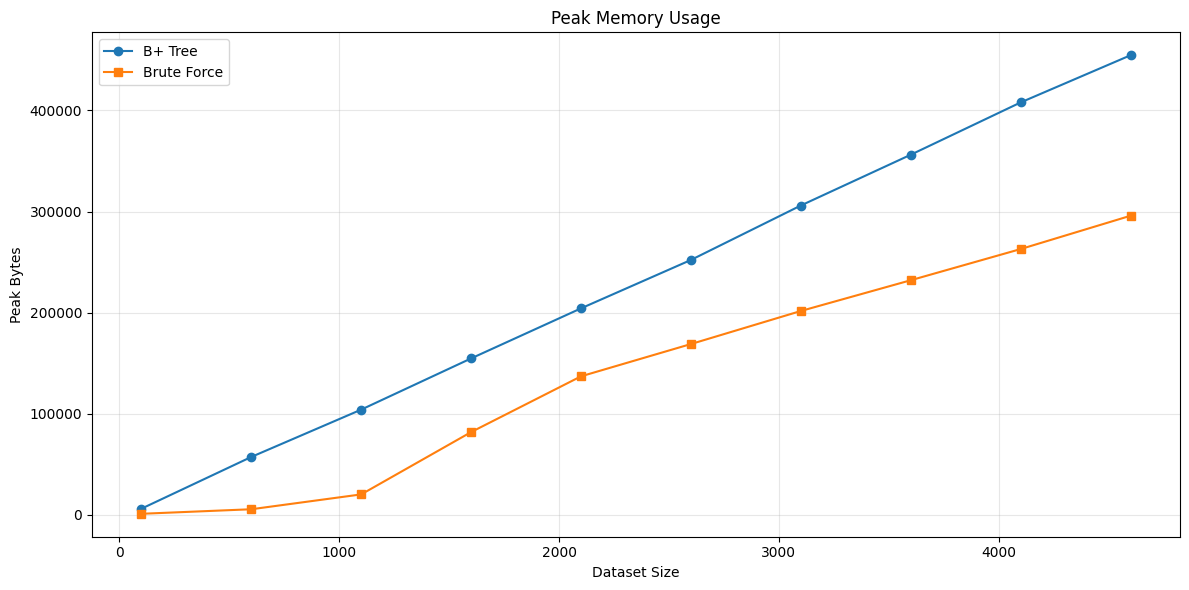

,size,operation,bplustree_s,bruteforce_s,speedup_x
0,100,insert,1.965001e-04,0.000252,1.281933
1,100,search,8.000061e-07,0.000002,2.250000
2,100,range_query,8.399948e-06,0.000012,1.440482
3,100,delete,4.392000e-04,0.000274,0.622951
4,600,insert,2.100100e-03,0.009748,4.641684
5,600,search,9.000069e-07,0.000011,12.222093
6,600,range_query,4.329998e-05,0.000082,1.905311
7,600,delete,4.658300e-03,0.010429,2.238843
8,1100,insert,4.630100e-03,0.039237,8.474244
9,1100,search,1.400011e-06,0.000024,17.428488


In [13]:
analyzer = PerformanceAnalyzer(order=8, seed=42)

# Quick run for notebook interactivity
quick_sizes = list(range(100, 5100, 500))
quick_results = analyzer.conduct_performance_testing(sizes=quick_sizes, repeat=5)
analyzer.plot_results(quick_results, show=True, save_dir=None)

# Compact summary table
summary_rows = []
for size in quick_sizes:
    for op in ('insert', 'search', 'range_query', 'delete'):
        row = {
            'size': size,
            'operation': op,
            'bplustree_s': quick_results['summary'][size][op]['bplustree_seconds'],
            'bruteforce_s': quick_results['summary'][size][op]['bruteforce_seconds'],
            'speedup_x': quick_results['summary'][size][op]['speedup_vs_bruteforce'],
        }
        summary_rows.append(row)

pd.DataFrame(summary_rows).head(12)

In [21]:
# Full scale run
full_sizes = list(range(100, 10001, 1000)) + list(range(20000, 100000, 10000))

full_results = analyzer.conduct_performance_testing(sizes=full_sizes, repeat=3)
analyzer.plot_results(full_results, show=True, save_dir='plots')

KeyboardInterrupt: 